Dit notebook is om de de effecten van de preprocessingen stappen op een enkel spectrum te visualiseren. Dit is om de effecten van de preprocessing stappen te visualiseren zodat dit gebruikt kan worden in de eindpresentatie.

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Add the parent directory (project root) to Python path FIRST
project_root = os.path.abspath('..')  # Go up one level from current notebook
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Clear any cached imports
import importlib
if 'utils.libs_generic_functions' in sys.modules:
    importlib.reload(sys.modules['utils.libs_generic_functions'])

# NOW import after path is set up
from utils.baseline_correction_functions import BaselineCorrector
from utils.libs_generic_functions import LibsDataLoader, LibsDataPreprocessor, plot_single_spectrum

print("✅ All imports successful!")
print(f"📁 Project root: {project_root}")
print(f"📦 plot_single_spectrum imported: {plot_single_spectrum}")


✅ All imports successful!
📁 Project root: c:\Users\joost\Documents\GitHub
📦 plot_single_spectrum imported: <function plot_single_spectrum at 0x000001DC3B880790>


In [2]:
dataloader = LibsDataLoader(data_directory='data')
preprocessor = LibsDataPreprocessor()
corrector = BaselineCorrector()

In [3]:
df = dataloader.load_all_measurements_no_rounding()

MEMORY-EFFICIENT LOADING OF ALL INDIVIDUAL MEASUREMENTS
First pass: Counting measurements...
Processing file 1/316: 2024-11-05T11-26-41_nr-001_B1_tread_aided_10Hz_280A.h5
Processing file 11/316: 2024-11-05T11-51-23_nr-011_B4_innerliner_aided_10Hz_280A.h5
Processing file 21/316: 2024-11-05T12-02-34_nr-021_B7_sidewall_aided_10Hz_280A.h5
Processing file 31/316: 2024-11-05T12-13-30_nr-031_B22_tread_aided_10Hz_280A.h5
Processing file 41/316: 2024-11-05T12-25-42_nr-041_B33_innerliner_aided_10Hz_280A.h5
Processing file 51/316: 2024-11-05T12-36-31_nr-051_B28_sidewall_aided_10Hz_280A.h5
Processing file 61/316: 2024-11-05T12-47-29_nr-061_B15_tread_aided_10Hz_280A.h5
  Counted 10,000 measurements...
Processing file 71/316: 2024-11-05T12-58-45_nr-071_B30_innerliner_aided_10Hz_280A.h5
Processing file 81/316: 2024-11-05T13-17-11_nr-081_B35_innerliner_aided_10Hz_280A.h5
Processing file 91/316: 2024-11-05T14-05-16_nr-091_B26_sidewall_aided_10Hz_280A.h5
Processing file 101/316: 2024-11-05T14-16-52_nr-1

In [4]:
non_feature_cols = ['tire_number', 'origin', 'measurement_id']
print(f"Non-feature columns: {non_feature_cols}")

# Get numeric columns (wavelength data)
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
wavelength_columns = [col for col in numeric_columns if col not in non_feature_cols]

Non-feature columns: ['tire_number', 'origin', 'measurement_id']


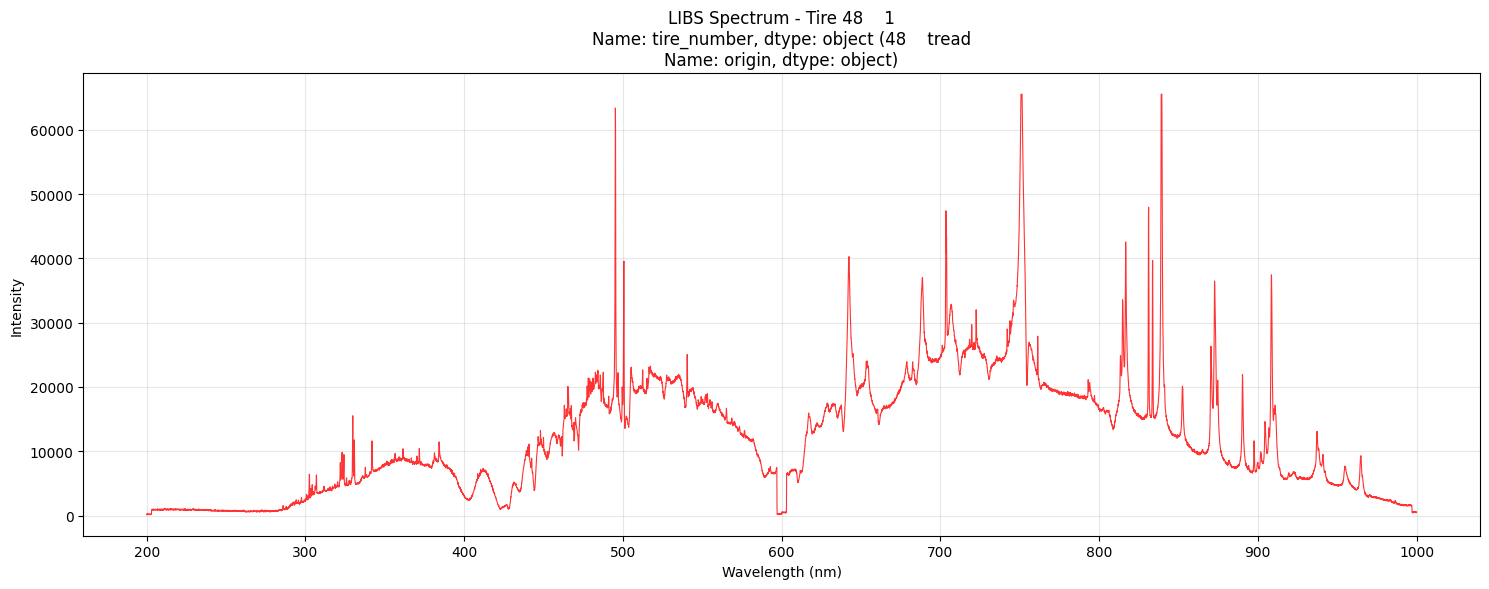

In [5]:
row_series = df.loc[48]
single_tire_data = row_series.to_frame().T
# single_tire_data = df.loc[47]

# Extract wavelength data - use the actual column names
wavelength_values = [float(col) for col in wavelength_columns]
intensity_values = [single_tire_data[col] for col in wavelength_columns]

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(wavelength_values, intensity_values, linewidth=0.8, alpha=0.8, color='red')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Intensity')
ax.set_title(f'LIBS Spectrum - Tire {single_tire_data["tire_number"]} ({single_tire_data["origin"]})')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
from utils.saturation_functions import run_complete_saturation_analysis, apply_voigt_saturation_correction, plot_voigt_correction_examples

single_tire_data_voigt = apply_voigt_saturation_correction(
    df=single_tire_data,
)


🔧 Voigt Profile Saturation Correction
Total measurements: 1
Saturated measurements: 1
Processing measurements: 1
Saturation threshold: 65535
Minimum peak width: 3
Progress: 1/1 (100.0%)

📊 Correction Summary:
------------------------------
Measurements processed: 1
Measurements corrected: 1
Success rate: 100.0%
Total peaks found: 2
Total peaks corrected: 2
Peak correction rate: 100.0%

Intensity ranges:
Original max: 65,535
Corrected max: 79,986
Max increase: 1.22x


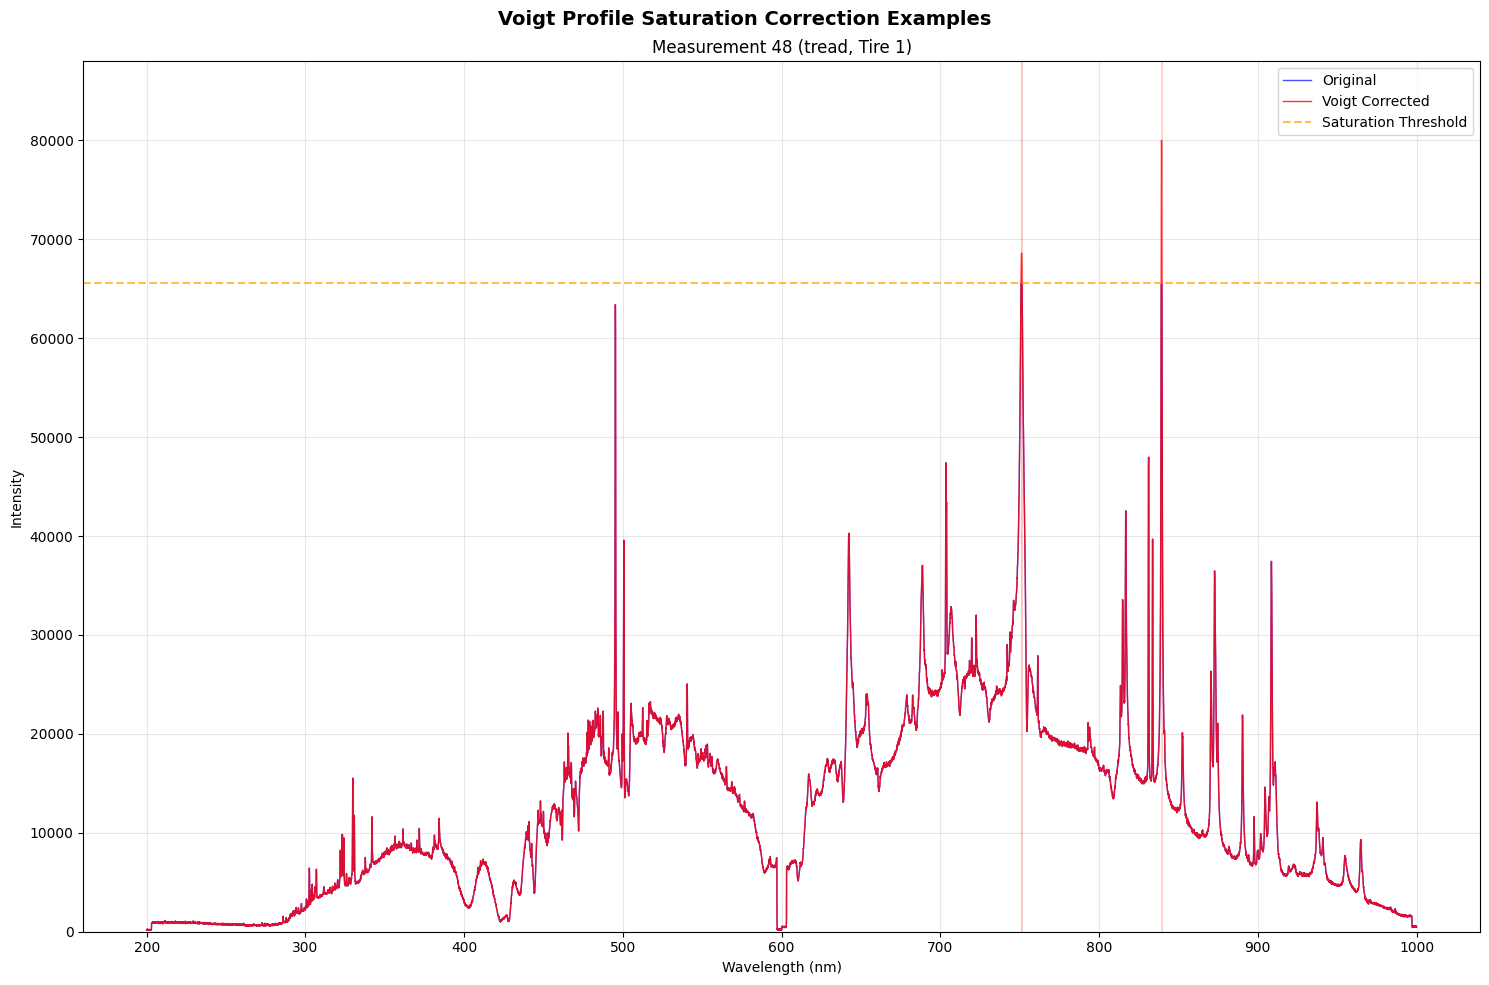

In [7]:
plot_voigt_correction_examples(single_tire_data, single_tire_data_voigt, n_examples=1)

Processing DataFrame with 1 rows and 8191 columns
Auto-detected 8188 spectral columns
Extracted spectral matrix: 1 spectra x 8188 wavelengths
Applying HYBRID baseline correction to 1 spectra in batches of 100...
  Processing batch 1/1 (rows 1-1)
Baseline correction completed! Returning corrected DataFrame.


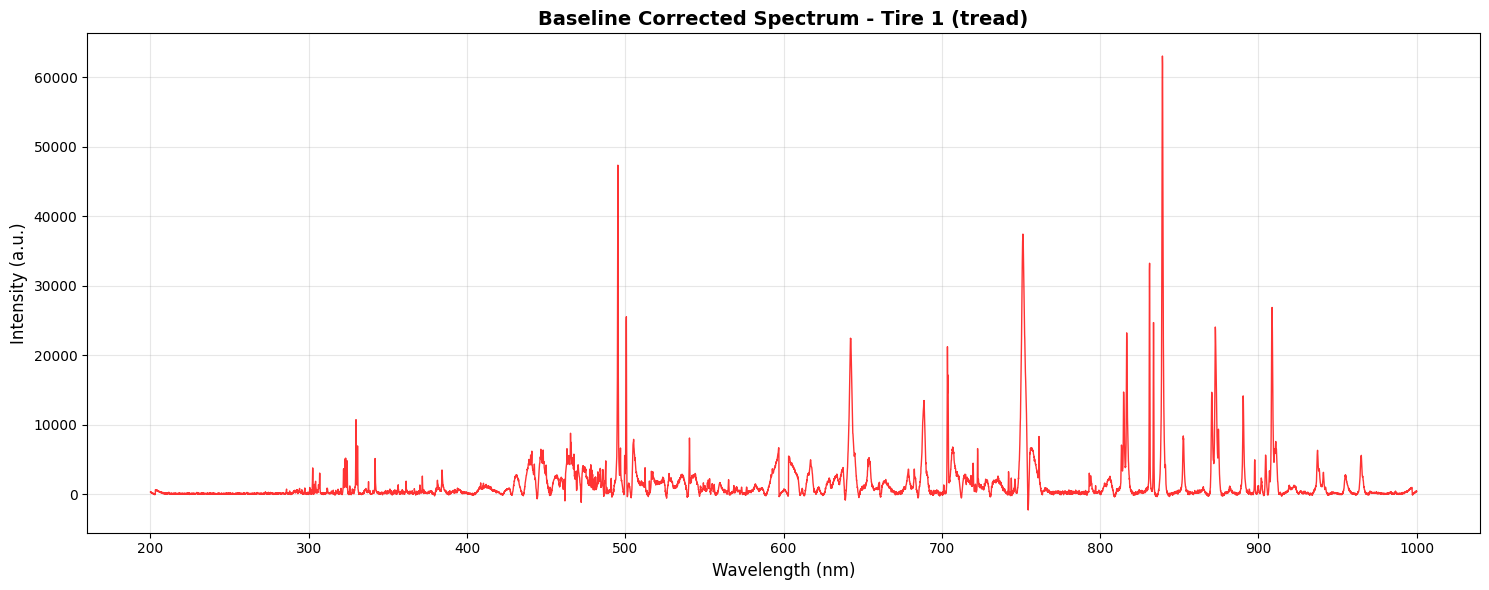

In [8]:
from utils.baseline_correction_functions import apply_baseline_correction_to_dataframe

single_tire_data_baseline_corrected = apply_baseline_correction_to_dataframe(
    df=single_tire_data_voigt)

# Extract only the numeric wavelength columns
non_feature_cols = ['tire_number', 'origin', 'measurement_id']

# Get all numeric columns (wavelengths)
wavelength_columns = [col for col in single_tire_data_baseline_corrected.columns 
                      if col not in non_feature_cols]

# Extract wavelengths and intensities
wavelengths = np.array([float(col) for col in wavelength_columns])
intensities = single_tire_data_baseline_corrected[wavelength_columns].values.flatten()

# Get metadata for the title
tire_num = single_tire_data_baseline_corrected['tire_number'].values[0]
origin = single_tire_data_baseline_corrected['origin'].values[0]

# Now plot
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(wavelengths, intensities, linewidth=1, color='red', alpha=0.8)
ax.set_xlabel('Wavelength (nm)', fontsize=12)
ax.set_ylabel('Intensity (a.u.)', fontsize=12)
ax.set_title(f'Baseline Corrected Spectrum - Tire {tire_num} ({origin})', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Normalization applied:
  Original - Mean: 1513.71, Std: 3561.12
  Normalized - Mean: -0.000000, Std: 1.000000


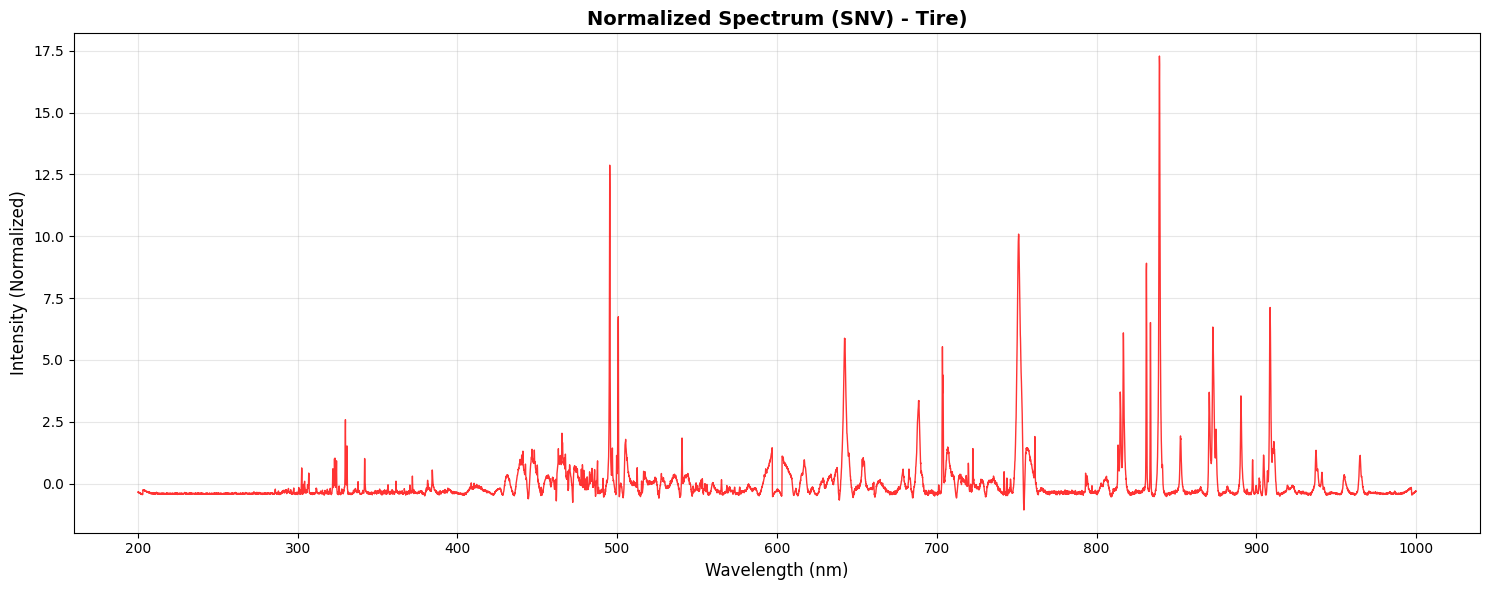

In [14]:
from utils.normalization_functions import Normalizer

normalizer = Normalizer()

# For a single spectrum, we need to normalize across wavelengths (row-wise), not columns
# Extract only wavelength columns first
non_feature_cols = ['tire_number', 'origin', 'measurement_id']
wavelength_columns = [col for col in single_tire_data_baseline_corrected.columns 
                      if col not in non_feature_cols]

# Get the spectrum values
spectrum_values = single_tire_data_baseline_corrected[wavelength_columns].values

# Apply SNV normalization row-wise (across wavelengths)
spectrum_mean = np.mean(spectrum_values)
spectrum_std = np.std(spectrum_values, ddof=0)

if spectrum_std == 0:
    spectrum_std = 1  # Prevent division by zero

normalized_spectrum_values = (spectrum_values - spectrum_mean) / spectrum_std

# Create a new DataFrame with normalized values
single_tire_data_normalized = single_tire_data_baseline_corrected.copy()
single_tire_data_normalized[wavelength_columns] = normalized_spectrum_values

print(f"Normalization applied:")
print(f"  Original - Mean: {spectrum_mean:.2f}, Std: {spectrum_std:.2f}")
print(f"  Normalized - Mean: {np.mean(normalized_spectrum_values):.6f}, Std: {np.std(normalized_spectrum_values, ddof=0):.6f}")

# Plot the normalized spectrum
wavelengths = np.array([float(col) for col in wavelength_columns])
intensities = normalized_spectrum_values.flatten()

# Get metadata for the title
# tire_num = single_tire_data_baseline_corrected['tire_number'].values[0]
# origin = single_tire_data_baseline_corrected['origin'].values[0]

# Now plot
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(wavelengths, intensities, linewidth=1, color='red', alpha=0.8)
ax.set_xlabel('Wavelength (nm)', fontsize=12)
ax.set_ylabel('Intensity (Normalized)', fontsize=12)
ax.set_title(f'Normalized Spectrum (SNV) - Tire)', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
